# Meat and Shrimp Shelf-Life Database Processing

This notebook transforms two raw shelf-life datasets into analysis-ready outputs:

- **Meat database** (`meat_shelf_life.csv`): wide-format records reshaped to long format, column names normalized, missing chemical composition and source values filled via a curated mapping.
- **Shrimp database** (`shrimp_shelf_life.csv`): replicate-level time-series converted to pre/post-threshold summary rows that match the meat schema.

**Output files**
- `data/processed/meat_shelf_life_long.csv`
- `data/processed/shrimp_shelf_life_long.csv`

## Table of Contents

**Meat Database**

1. [Setup and Imports](#1-setup-and-imports)
2. [Load Raw Data](#2-load-raw-data)
3. [Cleaning and Standardization](#3-cleaning-and-standardization)
4. [Missing Value Handling](#4-missing-value-handling)
5. [Export](#5-export)

**Shrimp Database**

6. [Load Raw Data](#6-shrimp-load-raw-data)
7. [Define Thresholds and Ingredient Metadata](#7-define-thresholds-and-ingredient-metadata)
8. [Compute Shelf-Life Indicators](#8-compute-shelf-life-indicators)
9. [Export](#9-shrimp-export)

## Meat Database

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## 2. Load Raw Data

Read the raw meat database CSV into a DataFrame. Dashes (`-`) are treated as missing values.

In [2]:
meatdf = pd.read_csv("../data/raw/meat_shelf_life.csv", na_values=["-"])
meatdf.head()

,Article #,ingredient 1,Concentration,Unit of concentration,Normalized concentration % of meat,Chemical composition,source,ingredient 2,Concentration .1,Unit of concentration .1,...,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83
0,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,1.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
meatdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Article #                              531 non-null    object 
 1   ingredient 1                           531 non-null    object 
 2   Concentration                          452 non-null    float64
 3   Unit of concentration                  446 non-null    object 
 4   Normalized concentration % of meat     531 non-null    float64
 5   Chemical composition                   352 non-null    object 
 6   source                                 364 non-null    object 
 7   ingredient 2                           151 non-null    object 
 8   Concentration .1                       151 non-null    float64
 9   Unit of concentration .1               151 non-null    object 
 10  Normalized concentration %             145 non-null    float64
 11  Chemic

## 3. Cleaning and Standardization

Remove trailing empty columns and all-NaN rows, normalize column names to `snake_case`, remove unneeded columns, standardize the information and reshape the wide ingredient layout (up to four ingredient blocks) into a single long-format table.

### 3.1. Remove Unnamed Columns and Empty Rows

In [4]:
meatdf = meatdf.loc[:, ~meatdf.columns.astype(str).str.contains("Unnamed")]
meatdf = meatdf.dropna(how="all")

### 3.2. Normalize Columns

First, normalize column names and make sure all have the appropriate type.

In [5]:
def normalize_column_names(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace("-", "_")
    )
    return df

meatdf = normalize_column_names(meatdf)

meatdf['initial_count_(day_0)'] = pd.to_numeric(meatdf['initial_count_(day_0)'], errors='coerce')
meatdf['post_threshold_(day)'] = pd.to_numeric(meatdf['post_threshold_(day)'], errors='coerce')

In [6]:
def standardize_immersion_time(val):
    if pd.isna(val) or str(val).strip() == "":
        return None
    s = str(val).strip().lower()
    # Extract hours → convert to minutes
    m = re.search(r"(\d+(?:\.\d+)?)\s*hour", s)
    if m:
        return float(m.group(1)) * 60
    # Extract minutes
    m = re.search(r"(\d+(?:\.\d+)?)\s*min", s)
    if m:
        return float(m.group(1))
    # Non-time descriptions
    return None

meatdf["immersion_time"] = meatdf["immersion_time"].apply(standardize_immersion_time)
print(meatdf["immersion_time"].value_counts(dropna=False))

immersion_time
NaN       390
30.0       56
2.0        55
10.0       18
1440.0      6
1.0         3
60.0        3
Name: count, dtype: int64


### 3.2.1. Standardize Packaging Condition

Normalize the free-text `packaging_condition` column into structured attributes:
`packaging_atmosphere`, `packaging_material`, `container_type`, `gas_CO2`, `gas_O2`,
`gas_N2`, and `special_properties`. The original `packaging_condition` value is
preserved unchanged. Processing runs on the pre-reshape wide frame so all output
columns propagate automatically through `metadata_cols` into the long format.

**Pipeline stages:**
1. Text normalization — lowercase, OCR corrections, punctuation cleanup
2. Ontology matching — exact keyword scan, then fuzzy fallback via RapidFuzz
3. Gas composition extraction — regex over structured `%` notation
4. Classification — orchestrator returns a dict per row
5. Apply to frame — expand dict columns, report unresolved rows

In [7]:
_OCR_CORRECTIONS = {
    "vaccuum":        "vacuum",
    "vaccum":         "vacuum",
    "aeorobic":       "aerobic",
    "aerobica":       "aerobic",
    "carboard":       "cardboard",
    "iluminated":     "illuminated",
    "poly- ethylene": "polyethylene",
    "poly-ethylene":  "polyethylene",
    "polyethene":     "polyethylene",
    "polythene":      "polyethylene",
    "ldpe/ pa":       "ldpe pa",
    "ldpe/pa":        "ldpe pa",
    "ldpe /pa":       "ldpe pa",
}


def normalize_packaging_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    s = text.strip().lower()
    for wrong, right in _OCR_CORRECTIONS.items():
        s = s.replace(wrong, right)
    s = re.sub(r"[/()\[\],]", " ", s)
    s = re.sub(r"\s*-\s*", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [8]:
ATMOSPHERE_ONTOLOGY: dict[str, list[str]] = {
    "Vacuum":  ["vacuum", "vacuum packaged", "vacuum packaging", "vacuum packed"],
    "MAP":     ["map", "modified atmosphere"],
    "Aerobic": ["aerobic", "aerobically", "air"],
}

MATERIAL_ONTOLOGY: dict[str, list[str]] = {
    "LDPE":           ["ldpe", "low density polyethylene", "polyethylene"],
    "PA":             ["pa", "polyamide"],
    "PP":             ["pp", "polypropylene"],
    "PS":             ["ps", "polystyrene"],
    "Cellulose":      ["cellulose"],
    "Protein film":   ["whey protein", "protein isolate"],
    "Caseinate film": ["sodium caseinate", "caseinate"],
}

CONTAINER_ONTOLOGY: dict[str, list[str]] = {
    "Tray":   ["tray", "trays"],
    "Bag":    ["bag", "bags"],
    "Pouch":  ["pouch", "pouches"],
    "Tube":   ["tube", "tubes"],
    "Box":    ["box", "boxes", "cardboard"],
    "Film":   ["film", "films"],
    "Casing": ["casing", "casings"],
}

SPECIAL_ONTOLOGY: dict[str, list[str]] = {
    "Barrier":          ["barrier"],
    "Oxygen-permeable": ["oxygen permeable", "o2 permeable"],
    "Active packaging": ["active packaging"],
}

In [9]:
from rapidfuzz import process as rf_process, fuzz as rf_fuzz

_FUZZY_THRESHOLD = 85


def _flatten_keywords(ontology: dict) -> dict[str, str]:
    return {kw: label for label, keywords in ontology.items() for kw in keywords}


def _ngrams(text: str, n: int) -> list[str]:
    tokens = text.split()
    return [" ".join(tokens[i: i + n]) for i in range(len(tokens) - n + 1)]


def match_ontology(
    normalized_text: str,
    ontology: dict,
    threshold: int = _FUZZY_THRESHOLD,
    multi: bool = False,
) -> list[str] | str | None:
    kw_to_label = _flatten_keywords(ontology)
    matched: list[str] = []

    # Pass 1: exact substring scan
    for kw, label in kw_to_label.items():
        if kw in normalized_text and label not in matched:
            matched.append(label)

    # Pass 2: RapidFuzz WRatio on unigrams + bigrams
    if not matched or multi:
        candidates = _ngrams(normalized_text, 1) + _ngrams(normalized_text, 2)
        all_kws = list(kw_to_label.keys())
        for cand in candidates:
            result = rf_process.extractOne(cand, all_kws, scorer=rf_fuzz.WRatio)
            if result and result[1] >= threshold:
                label = kw_to_label[result[0]]
                if label not in matched:
                    matched.append(label)

    if not matched:
        return [] if multi else None
    return matched if multi else matched[0]


_GAS_PATTERN = re.compile(r"(\d+(?:\.\d+)?)\s*%\s*(co2|o2|n2)", re.IGNORECASE)
_GAS_COLUMN_MAP = {"co2": "gas_CO2", "o2": "gas_O2", "n2": "gas_N2"}


def extract_gas_composition(normalized_text: str) -> dict:
    result = {"gas_CO2": None, "gas_O2": None, "gas_N2": None}
    for m in _GAS_PATTERN.finditer(normalized_text):
        col = _GAS_COLUMN_MAP.get(m.group(2).lower())
        if col:
            result[col] = float(m.group(1))
    return result

In [10]:
_UNKNOWN = "Unknown"
_PACKAGING_OUTPUT_COLS = [
    "packaging_atmosphere",
    "packaging_material",
    "container_type",
    "gas_CO2",
    "gas_O2",
    "gas_N2",
    "special_properties",
]


def classify_packaging(raw_text) -> dict:
    original = raw_text if isinstance(raw_text, str) else ""
    normalized = normalize_packaging_text(raw_text)

    atmosphere = match_ontology(normalized, ATMOSPHERE_ONTOLOGY, multi=False) or _UNKNOWN
    materials  = match_ontology(normalized, MATERIAL_ONTOLOGY,  multi=True)
    material_str = "|".join(materials) if materials else _UNKNOWN
    container  = match_ontology(normalized, CONTAINER_ONTOLOGY, multi=False) or _UNKNOWN
    gases      = extract_gas_composition(normalized)
    specials   = match_ontology(normalized, SPECIAL_ONTOLOGY,   multi=True)
    special_str = "|".join(specials) if specials else "None"

    return {
        "packaging_atmosphere": atmosphere,
        "packaging_material":   material_str,
        "container_type":       container,
        "gas_CO2":              gases["gas_CO2"],
        "gas_O2":               gases["gas_O2"],
        "gas_N2":               gases["gas_N2"],
        "special_properties":   special_str,
        "packaging_condition":  original,
    }


# Spot-check on representative values
_spot_checks = [
    "Vacuum packaged",
    "MAP (65%CO2/30%N2/5%O2) LDPE/PA film tray",
    "aerobic LDPE bag",
    "vaccum packaged",
    "Modified atmosphere packaging",
    None,
]
print(f"{'Input':<45} {'atmosphere':<10} {'material':<12} {'container':<8} {'CO2':>5}")
print("-" * 85)
for v in _spot_checks:
    r = classify_packaging(v)
    print(f"{str(v):<45} {r['packaging_atmosphere']:<10} {r['packaging_material']:<12} "
          f"{r['container_type']:<8} {str(r['gas_CO2']):>5}")

Input                                         atmosphere material     container   CO2
-------------------------------------------------------------------------------------
Vacuum packaged                               Vacuum     PA           Unknown   None
MAP (65%CO2/30%N2/5%O2) LDPE/PA film tray     MAP        LDPE|PA      Tray      65.0
aerobic LDPE bag                              Aerobic    LDPE         Bag       None
vaccum packaged                               Vacuum     PA           Unknown   None
Modified atmosphere packaging                 MAP        PA           Unknown   None
None                                          Unknown    Unknown      Unknown   None


In [11]:
_packaging_classified = meatdf["packaging_condition"].apply(classify_packaging)
_packaging_expanded   = pd.DataFrame(_packaging_classified.tolist(), index=meatdf.index)

_pc_loc = meatdf.columns.get_loc("packaging_condition")
for i, col in enumerate(_PACKAGING_OUTPUT_COLS):
    meatdf.insert(_pc_loc + 1 + i, col, _packaging_expanded[col])

# Unresolved: all three main categories unknown but input was non-null
_is_unresolved = (
    (meatdf["packaging_atmosphere"] == _UNKNOWN)
    & (meatdf["container_type"]      == _UNKNOWN)
    & (meatdf["packaging_material"]  == _UNKNOWN)
    & meatdf["packaging_condition"].notna()
    & (meatdf["packaging_condition"].astype(str).str.strip() != "")
)
unresolved_report = (
    meatdf.loc[_is_unresolved, ["packaging_condition"] + _PACKAGING_OUTPUT_COLS]
    .drop_duplicates(subset=["packaging_condition"])
    .reset_index(drop=True)
)

print(f"Classified {len(meatdf)} rows.")
print(f"Atmosphere distribution:\n{meatdf['packaging_atmosphere'].value_counts(dropna=False)}\n")
print(f"Unresolved entries ({len(unresolved_report)}):")
display(unresolved_report)

Classified 531 rows.
Atmosphere distribution:
packaging_atmosphere
Unknown    279
MAP        101
Aerobic     88
Vacuum      63
Name: count, dtype: int64

Unresolved entries (2):


,packaging_condition,packaging_atmosphere,packaging_material,container_type,gas_CO2,gas_O2,gas_N2,special_properties
0,marinated,Unknown,Unknown,Unknown,NaN,NaN,NaN,None
1,none,Unknown,Unknown,Unknown,NaN,NaN,NaN,None


### 3.2.2. Consolidate Packaging into `packaging_class`

`packaging_atmosphere` and `packaging_condition` are redundant — atmosphere is literally
derived from condition's free text — so training a GAN on both risks it learning
contradictory pairs (e.g. atmosphere=Vacuum alongside a condition string mentioning "aerobic").

Collapse them into a single `packaging_class` column. The `Active_Antimicrobial` value is
only assigned when `special_properties` (itself ontology-derived from the same source text)
already flags `"Active packaging"` — this is evidence-backed, not a new relationship invented
between unrelated columns. `packaging_material` stays independent per the original ontology;
no relationship between material and gas composition is encoded since none is supported by
the data.

In [12]:
def to_packaging_class(atmosphere: str, special_properties: str) -> str:
    if atmosphere == _UNKNOWN:
        return _UNKNOWN
    if isinstance(special_properties, str) and "Active packaging" in special_properties.split("|"):
        return "Active_Antimicrobial"
    return atmosphere


meatdf["packaging_class"] = meatdf.apply(
    lambda row: to_packaging_class(row["packaging_atmosphere"], row["special_properties"]),
    axis=1,
)

_pa_loc = meatdf.columns.get_loc("packaging_atmosphere")
meatdf.insert(_pa_loc, "packaging_class", meatdf.pop("packaging_class"))
meatdf.drop(columns=["packaging_atmosphere"], inplace=True)

print(meatdf["packaging_class"].value_counts(dropna=False))

packaging_class
Unknown                 279
Active_Antimicrobial    185
Aerobic                  30
MAP                      23
Vacuum                   14
Name: count, dtype: int64


### 3.2.3. Drop Redundant Gas Dimension

`gas_CO2 + gas_O2 + gas_N2` always sums to 100% wherever gas composition is recorded
(verified against the raw data), so `gas_N2` carries no information beyond what `gas_CO2`
and `gas_O2` already encode. Dropping it here keeps the GAN from training on a column whose
value is fully determined by two others. `data_filling.ipynb` reconstructs it deterministically
after sampling: `gas_N2 = 100 - gas_CO2 - gas_O2`, applied only when both CO2 and O2 are present.

In [13]:
meatdf.drop(columns=["gas_N2"], inplace=True)
_PACKAGING_OUTPUT_COLS = [c for c in _PACKAGING_OUTPUT_COLS if c not in ("packaging_atmosphere", "gas_N2")] + ["packaging_class"]
print(meatdf.columns.tolist())

['article_#', 'ingredient_1', 'concentration', 'unit_of_concentration', 'normalized_concentration_%_of_meat', 'chemical_composition', 'source', 'ingredient_2', 'concentration_.1', 'unit_of_concentration_.1', 'normalized_concentration_%', 'chemical_chomposition', 'source', 'ingredient_3', 'concentration_.2', 'unit_of_concentration_.2', 'normalized_concentration', 'chemical_composition.1', 'source.1', 'ingredient_4', 'concentration_.3', 'unit_of_concentration_.3', 'normalized_concentration.1', 'chemical_composition', 'source.1', 'immersion_time', 'packaging_condition', 'packaging_class', 'packaging_material', 'container_type', 'gas_CO2', 'gas_O2', 'special_properties', 'storage_condition_(°c)', 'meat_type', 'meat_type_2', 'part_of_product', 'treatment', 'combined_treatment', 'indicators', 'type_of_indicator', 'lower_level_threshold_(log_cfu/g)', 'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count_(day_0)', 'pre_threshold_(day)', 'pre_threshold_count', 'efficacité_pre_threshols', 

#### Optional: Semantic Clustering of Unresolved Entries

Run the cell below (`RUN_OPTIONAL_CLUSTERING = True`) to group the `unresolved_report`
rows by semantic similarity using SentenceTransformers + AgglomerativeClustering.
This helps identify new keyword patterns to add to the ontology dictionaries above.

**Prerequisites:** `pip install sentence-transformers` (already in `requirements.txt`).

In [14]:
RUN_OPTIONAL_CLUSTERING = False

if RUN_OPTIONAL_CLUSTERING and len(unresolved_report) >= 2:
    try:
        from sentence_transformers import SentenceTransformer
        from sklearn.cluster import AgglomerativeClustering

        _texts = unresolved_report["packaging_condition"].tolist()
        _model = SentenceTransformer("all-MiniLM-L6-v2")
        _embeddings = _model.encode(_texts, show_progress_bar=False)

        n_clusters = min(6, len(_texts))
        _labels = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(_embeddings)

        for cluster_id in range(n_clusters):
            members = [t for t, l in zip(_texts, _labels) if l == cluster_id]
            print(f"Cluster {cluster_id}: {members}")
    except ImportError:
        print("sentence-transformers not installed. Run: pip install sentence-transformers")
elif len(unresolved_report) < 2:
    print("Not enough unresolved entries to cluster.")

In [15]:
meatdf.drop(columns=["packaging_condition"], inplace=True)

Next, decompose the `treatment` and `combined_treatment` columns into three orthogonal
categorical axes instead of a flattened `"anm+heat"`-style string. This lets the GAN
(in `data_filling.ipynb`) learn each hurdle dimension independently rather than treating
every token combination as an unrelated category:

- `physical_hurdle_tech` — the physical intervention applied (`Heat`, `Irradiation`), if any.
- `application_method` — the chemical/process application (`ANM`, `Salt`, `MAP`), if any.
- `hurdle_coordination` — `Single` (one token) or `Hybrid_Simultaneous` (multiple `+`-joined
  tokens). The real data only contains simultaneous combinations (no sequential-application
  records exist), so `Hybrid_Sequential` is intentionally not modeled here — adding it without
  any supporting rows would just give the GAN an unlearnable category.
- `irradiation_dose` — the numeric dose extracted from `irradiation_N` tokens, kept as its own
  numeric column since the dose itself carries information beyond "irradiation was used".

The original `treatment`/`combined_treatment` strings are dropped after derivation, alongside
the redundant `meat_type_2` column.

In [16]:
PATTERNS = {
    "anm": [
        r"\banm\b",
        r"antimicrobial"
    ],
    "map": [
        r"\bmap\b"
    ],
    "salt": [
        r"salt"
    ],
    "heat": [
        r"autoclav",
        r"precook",
        r"cooked"
    ]
}

# Which axis each token belongs to. Discovered directly from PATTERNS above —
# not an independent assumption.
_PHYSICAL_HURDLE_TOKENS = {"heat": "Heat", "irradiation": "Irradiation"}
_APPLICATION_METHOD_TOKENS = {"anm": "ANM", "salt": "Salt", "map": "MAP"}


def extract_treatment_tokens(*values) -> tuple[set[str], int | None]:
    """Scan free-text treatment fields for PATTERNS tokens + an irradiation dose."""
    text = " ".join(
        str(v).lower()
        for v in values
        if v and str(v).strip()
    )

    tokens = {
        token
        for token, patterns in PATTERNS.items()
        if any(re.search(p, text) for p in patterns)
    }

    dose = None
    m = re.search(r"irradiation\s*(\d+)", text)
    if m:
        tokens.add("irradiation")
        dose = int(m.group(1))

    return tokens, dose


def decompose_treatment(*values) -> dict:
    tokens, dose = extract_treatment_tokens(*values)

    physical = sorted(_PHYSICAL_HURDLE_TOKENS[t] for t in tokens if t in _PHYSICAL_HURDLE_TOKENS)
    application = sorted(_APPLICATION_METHOD_TOKENS[t] for t in tokens if t in _APPLICATION_METHOD_TOKENS)

    if not tokens:
        coordination = None
    elif len(tokens) == 1:
        coordination = "Single"
    else:
        # Only simultaneous (+-joined) combinations are observed in this dataset —
        # no sequential-application records exist, so "Hybrid_Sequential" is not modeled.
        coordination = "Hybrid_Simultaneous"

    return {
        # Assumption beyond observed data: if multiple application-method tokens ever
        # co-occur (not seen in current data), they are joined by "+" rather than dropped.
        "physical_hurdle_tech": "+".join(physical) if physical else None,
        "application_method": "+".join(application) if application else None,
        "hurdle_coordination": coordination,
        "irradiation_dose": dose,
    }


_treatment_decomposed = meatdf.apply(
    lambda row: decompose_treatment(row["treatment"], row["combined_treatment"]),
    axis=1,
)
_treatment_expanded = pd.DataFrame(_treatment_decomposed.tolist(), index=meatdf.index)

_treat_loc = meatdf.columns.get_loc("treatment")
for i, col in enumerate(_treatment_expanded.columns):
    meatdf.insert(_treat_loc + 1 + i, col, _treatment_expanded[col])

meatdf.drop(columns=["treatment", "combined_treatment", "meat_type_2"], inplace=True)

print(meatdf[["physical_hurdle_tech", "application_method", "hurdle_coordination"]].value_counts(dropna=False))

physical_hurdle_tech  application_method  hurdle_coordination
NaN                   ANM                 Single                 244
                      NaN                 NaN                    165
                      ANM+MAP             Hybrid_Simultaneous     75
                      ANM+Salt            Hybrid_Simultaneous     12
Heat                  ANM                 Hybrid_Simultaneous      9
Irradiation           NaN                 Single                   8
Heat                  NaN                 Single                   7
Irradiation           ANM                 Hybrid_Simultaneous      5
                      MAP                 Hybrid_Simultaneous      3
NaN                   Salt                Single                   3
Name: count, dtype: int64


Many of the numerical columns considered for the meat database could be foregone for now, as they have implicit dependencies/ arbitrary classifications that may influence the final results.
As such, we will only keep the following computed values: 

 - '`initial_inhibition_factor`':  (pre-threshold_count - initial_count) / pre-threshold_day 
 - '`post_inhibition_factor`': (post-threshold_count - pre-threshold_count)/(post-threshold_day- pre-threshold_day)
 - '`post_threshold_proximity_index_1(tpi)`': post-threshold_count/lower_level_threshold

In [17]:
meatdf.columns

Index(['article_#', 'ingredient_1', 'concentration', 'unit_of_concentration',
       'normalized_concentration_%_of_meat', 'chemical_composition', 'source',
       'ingredient_2', 'concentration_.1', 'unit_of_concentration_.1',
       'normalized_concentration_%', 'chemical_chomposition', 'source',
       'ingredient_3', 'concentration_.2', 'unit_of_concentration_.2',
       'normalized_concentration', 'chemical_composition.1', 'source.1',
       'ingredient_4', 'concentration_.3', 'unit_of_concentration_.3',
       'normalized_concentration.1', 'chemical_composition', 'source.1',
       'immersion_time', 'packaging_class', 'packaging_material',
       'container_type', 'gas_CO2', 'gas_O2', 'special_properties',
       'storage_condition_(°c)', 'meat_type', 'part_of_product',
       'physical_hurdle_tech', 'application_method', 'hurdle_coordination',
       'irradiation_dose', 'indicators', 'type_of_indicator',
       'lower_level_threshold_(log_cfu/g)',
       'upper_level_threshold_(

In [18]:
meatdf.drop(columns=['efficacité_pre_threshols', 'pre_threshold_proximity_index_1(tpi)',
       'pre_threshold_proximity_index_2(tpi)',
       'efficacité_pre_threshols_proximity', 'efficacité_of_post_threshold', 'efficiency','post_threshold_proximity_index_1(tpi)',
       'efficacité_post_threshols_proximity'], inplace=True)

### 3.3. Reshape to Long Format

Each source row contains up to four ingredient blocks (columns `ingredient_1` through `ingredient_4`, each with concentration, unit, normalized concentration, chemical composition, and source). This step unpivots those blocks into one row per ingredient, then drops rows where no ingredient was recorded.

In [19]:
metadata_start = meatdf.columns.get_loc("immersion_time")
metadata_cols = meatdf.columns[metadata_start:]

ingredient_blocks = []

for i in range(1, 5):
    ingredient_blocks.append(
        pd.DataFrame({
            "article_#": meatdf["article_#"],
            "ingredient_id": i,
            "ingredient": meatdf[f"ingredient_{i}"],
            "concentration": meatdf.iloc[:, 1 + (i - 1) * 6 + 1],
            "unit_of_concentration": meatdf.iloc[:, 1 + (i - 1) * 6 + 2],
            "normalized_concentration_%_of_meat": meatdf.iloc[:, 1 + (i - 1) * 6 + 3],
            "chemical_composition": meatdf.iloc[:, 1 + (i - 1) * 6 + 4],
            "source": meatdf.iloc[:, 1 + (i - 1) * 6 + 5],
        }).join(meatdf[metadata_cols])
    )

meatdf_long = (
    pd.concat(ingredient_blocks, ignore_index=True)
      .dropna(subset=["ingredient"])
      .reset_index(drop=True)
)

meatdf = meatdf_long

### 3.4. Normalize String Values

Strip whitespace and lowercase all string columns. Rows with a normalized concentration of 0% are labelled `"control"` before normalization so the label is preserved in lowercase.

In [20]:
def normalize_string_values(df):
    str_cols = df.select_dtypes(exclude="number").columns
    df[str_cols] = df[str_cols].fillna("").apply(lambda s: s.str.strip().str.lower())
    return df

meatdf.loc[
    pd.to_numeric(meatdf["normalized_concentration_%_of_meat"], errors="coerce").eq(0),
    "ingredient"
] = "control"

meatdf = normalize_string_values(meatdf)

## 4. Missing Value Handling

After reshaping, some rows are missing `chemical_composition` or `source`. This section identifies those rows and fills them using a curated ingredient-to-metadata mapping.

### 4.1. Visualize Missing Data Pattern

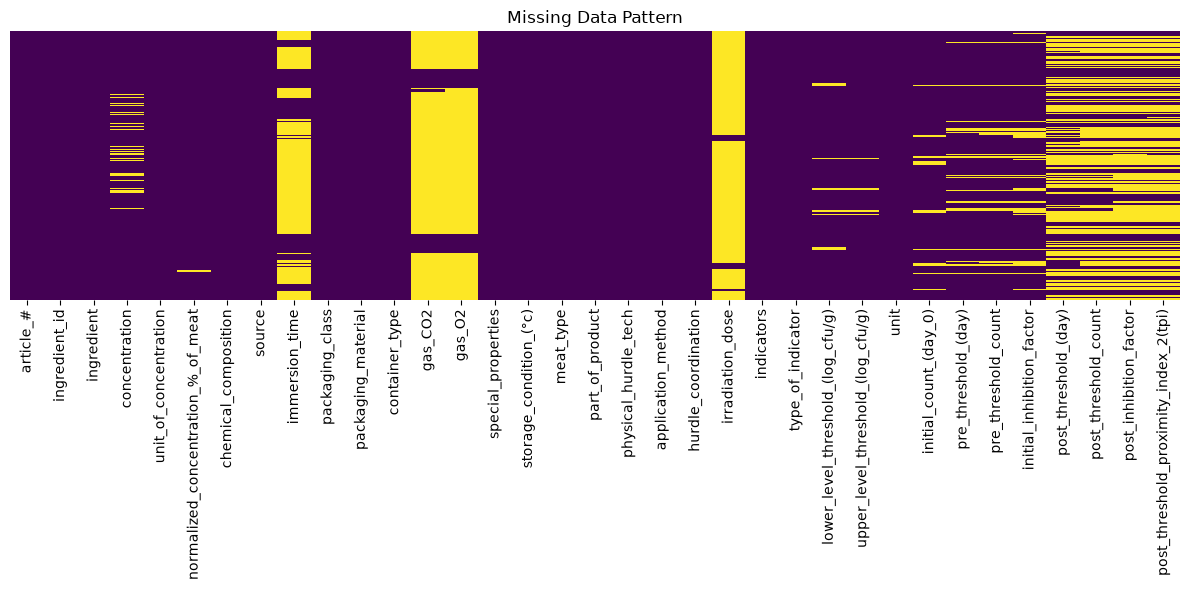

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(meatdf.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Pattern")
plt.tight_layout()
plt.show()

In [22]:
null_chem_source = meatdf[meatdf["chemical_composition"].isna() | meatdf["source"].isna()]

print("Rows with null chemical_composition or source:", len(null_chem_source))
print("Ingredients affected:", null_chem_source["ingredient"].dropna().unique())

null_chem_source[[
    "article_#",
    "ingredient_id",
    "ingredient",
    "chemical_composition",
    "source"
]].drop_duplicates().sort_values(["ingredient_id", "ingredient"])

Rows with null chemical_composition or source: 0
Ingredients affected: []


,article_#,ingredient_id,ingredient,chemical_composition,source


### 4.2. Fill Missing Chemical Composition and Source

Rows whose `ingredient` name matches a key in `INGREDIENT_METADATA` (substring match) receive the corresponding `chemical_composition` and `source` values. Control rows are labelled explicitly.

In [23]:
meatdf.loc[meatdf["ingredient"] == "control", ["chemical_composition", "source"]] = ("none", "none")
meatdf.loc[406, "ingredient"] = "rosemary"

INGREDIENT_METADATA = {
    "chlorine dioxide":         ("mineral",                          "other natural sources"),
    "so2":                      ("mineral",                          "other natural sources"),
    "sodium benzoate":          ("organic acid",                     "other natural sources"),
    "sodium ascorbate":         ("organic acid",                     "plant"),
    "sodium chloride":          ("mineral",                          "other natural sources"),
    "bha/bht":                  ("organic compound (antioxidant)",   "other natural sources"),
    "activin":                  ("polyphenol",                       "plant"),
    "bha":                      ("organic compound (antioxidant)",   "other natural sources"),
    "pycnogenol":               ("polyphenol",                       "plant"),
    "rosemary":                 ("essential oil / polyphenol",       "plant"),
    "stpp":                     ("mineral",                          "other natural sources"),
    "α-tocopherol":             ("vitamin",                          "plant"),
    "alpha-tocopherol":         ("vitamin",                          "plant"),
    "bht":                      ("organic compound (antioxidant)",   "other natural sources"),
    "sodium erythorbate":       ("organic acid",                     "microbial"),
    "nitrate":                  ("mineral",                          "other natural sources"),
    "edta / na2edta":           ("chelating agent (organic compound)", "other natural sources"),
    "edta":                     ("chelating agent (organic compound)", "other natural sources"),
    "thyme oil":                ("essential oil",                    "plant"),
    "turmeric oil":             ("essential oil",                    "plant"),
    "texturized soy":           ("protein",                          "plant"),
    "texturized soya":          ("protein",                          "plant"),
    "pea fi":                   ("fiber",                            "plant"),
}

def is_missing(col):
    return col.isna() | (col.astype(str).str.strip() == "")

ingred = meatdf["ingredient"].astype(str).str.strip().str.lower()
assigned = {"chemical_composition": 0, "source": 0}

for key, (chem_val, src_val) in INGREDIENT_METADATA.items():
    mask = ingred.str.contains(key, na=False, regex=False)
    if not mask.any():
        continue
    chem_mask = mask & is_missing(meatdf["chemical_composition"])
    if chem_mask.any():
        meatdf.loc[chem_mask, "chemical_composition"] = chem_val
        assigned["chemical_composition"] += chem_mask.sum()
    src_mask = mask & is_missing(meatdf["source"])
    if src_mask.any():
        meatdf.loc[src_mask, "source"] = src_val
        assigned["source"] += src_mask.sum()

print(f"Filled {assigned['chemical_composition']} chemical_composition and {assigned['source']} source values.")

remaining = meatdf[is_missing(meatdf["chemical_composition"]) | is_missing(meatdf["source"])]
print(f"Remaining rows with missing values: {len(remaining)}")
if len(remaining):
    display(remaining[["article_#", "ingredient_id", "ingredient", "chemical_composition", "source"]]
            .drop_duplicates().sort_values(["ingredient_id", "ingredient"]))

Filled 107 chemical_composition and 107 source values.
Remaining rows with missing values: 0


## 5. Export

Tag all meat records as theoretically derived (literature values), then write to CSV.

In [24]:
meatdf["data_source"] = "theoretical"

OUTPUT_PATH = "../data/processed/meat_shelf_life_long.csv"
meatdf.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(meatdf):,} rows to {OUTPUT_PATH}")

Saved 748 rows to ../data/processed/meat_shelf_life_long.csv


In [25]:
print("Meat long-format columns:")
print(list(meatdf.columns))
print(f"\nShape: {meatdf.shape}")

Meat long-format columns:
['article_#', 'ingredient_id', 'ingredient', 'concentration', 'unit_of_concentration', 'normalized_concentration_%_of_meat', 'chemical_composition', 'source', 'immersion_time', 'packaging_class', 'packaging_material', 'container_type', 'gas_CO2', 'gas_O2', 'special_properties', 'storage_condition_(°c)', 'meat_type', 'part_of_product', 'physical_hurdle_tech', 'application_method', 'hurdle_coordination', 'irradiation_dose', 'indicators', 'type_of_indicator', 'lower_level_threshold_(log_cfu/g)', 'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count_(day_0)', 'pre_threshold_(day)', 'pre_threshold_count', 'initial_inhibition_factor', 'post_threshold_(day)', 'post_threshold_count', 'post_inhibition_factor', 'post_threshold_proximity_index_2(tpi)', 'data_source']

Shape: (748, 36)


## Shrimp Database 

The shrimp dataset contains replicate-level time-series measurements for four indicators: total viable count (TVC), trimethylamine nitrogen (TMAN), total volatile basic nitrogen (TVBN), and peroxide value (PV). Each replicate-by-indicator series is reduced to pre-threshold and post-threshold summary rows using the same schema as the meat database.

## 6. Load Raw Data

In [26]:
shrimpdf = pd.read_csv("../data/raw/shrimp_shelf_life.csv", na_values=["-"])
shrimpdf = normalize_column_names(shrimpdf)
shrimpdf.head()

,replicate,ingredient,day,peroxide_value,total_bacteria_count_log,tvb_n,tma_n
0,1.0,NT,1.0,0.000000,2.501972,0.654640,0.514360
1,2.0,NT,1.0,0.109852,2.464908,2.098021,0.161386
2,3.0,NT,1.0,0.206723,2.515180,0.435595,0.197998
3,1.0,NT,3.0,0.503731,2.829161,0.220075,0.000000
4,2.0,NT,3.0,0.393879,3.046019,0.205595,0.000000


## 7. Define Thresholds and Ingredient Metadata

Specify spoilage thresholds for each indicator and define the ingredient lookup table mapping treatment codes (as used in the raw data) to ingredient details.

In [27]:
# Chemical indicators
SHRIMP_LOW_TMAN = 5
SHRIMP_HIGH_TMAN = 15

SHRIMP_LOW_TVBN = 15
SHRIMP_HIGH_TVBN = 30

SHRIMP_LOW_PV = 5
SHRIMP_HIGH_PV = 10

# Microbial indicators
SHRIMP_LOW_TVC = 5
SHRIMP_HIGH_TVC = 7

indicator_config = {
    "total_bacteria_count_log": {
        "indicator": "tvc",
        "type_of_indicator": "microbial",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TVC,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TVC,
        "unit": "log cfu/g"
    },
    "tma_n": {
        "indicator": "tman",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TMAN,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TMAN,
        "unit": "mg n/100g"
    },
    "tvb_n": {
        "indicator": "tvbn",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TVBN,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TVBN,
        "unit": "mg n/100g"
    },
    "peroxide_value": {
        "indicator": "pv",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_PV,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_PV,
        "unit": "meq o2/kg"
    }
}

ingredients_dict = {
    "NT": {
        "ingredient": "control",
        "ingredient id": 1,
        "concentration": None,
        "unit": None,
        "chemical composition": None,
        "source": None
    },

    "PA": {
        "ingredient": "peracetic acid",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "ppm",
        "chemical composition": "organic acid",
        "source": "other natural sources"
    },

    "N5": {
        "ingredient": "nisin",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "MIC",
        "chemical composition": "protein",
        "source": "microbial"
    },

    "N10": {
        "ingredient": "nisin",
        "ingredient id": 1,
        "concentration": 1000,
        "unit": "MIC",
        "chemical composition": "protein",
        "source": "microbial"
    },

    "PAN": [
        {
            "ingredient": "nisin",
            "ingredient id": 1,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "protein",
            "source": "microbial"
        },
        {
            "ingredient": "peracetic acid",
            "ingredient id": 2,
            "concentration": 250,
            "unit": "ppm",
            "chemical composition": "organic acid",
            "source": "other natural sources"
        }
    ],

    "B5": {
        "ingredient": "brevibacillin",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "MIC",
        "chemical composition": "peptide",
        "source": "microbial"
    },

    "B10": {
        "ingredient": "brevibacillin",
        "ingredient id": 1,
        "concentration": 1000,
        "unit": "MIC",
        "chemical composition": "peptide",
        "source": "microbial"
    },

    "NB": [
        {
            "ingredient": "brevibacillin",
            "ingredient id": 1,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "peptide",
            "source": "microbial"
        },
        {
            "ingredient": "nisin",
            "ingredient id": 2,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "protein",
            "source": "microbial"
        }
    ],

    "F3": [
        {
            "ingredient": "sunflower lecithin",
            "ingredient id": 1,
            "concentration": 0.3,
            "unit": "%",
            "chemical composition": "lipid",
            "source": "plant"
        },
        {
            "ingredient": "lime extract",
            "ingredient id": 2,
            "concentration": 9.0,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "lime oil",
            "ingredient id": 3,
            "concentration": 9.5,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        },
        {
            "ingredient": "lemon oil",
            "ingredient id": 4,
            "concentration": 0.5,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        },
        {
            "ingredient": "orange oil",
            "ingredient id": 5,
            "concentration": 1.3,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        }
    ],

    "F4": [
        {
            "ingredient": "garlic extract",
            "ingredient id": 1,
            "concentration": 0.025,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "grape and blueberry",
            "ingredient id": 2,
            "concentration": 0.2,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "cranberry",
            "ingredient id": 3,
            "concentration": 0.2,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        }
    ]
}

## 8. Compute Shelf-Life Indicators

Add study-level metadata columns, then iterate over each ingredient-replicate-indicator combination to compute the last measurement before and first measurement after each spoilage threshold.

In [28]:
def explode_ingredient_metadata(ingredient_code):
    metadata = ingredients_dict[ingredient_code]
    return [metadata] if isinstance(metadata, dict) else metadata


def find_threshold_transition(df, value_col, threshold):
    df = df.sort_values("day")
    below = df[df[value_col] < threshold]
    above = df[df[value_col] >= threshold]

    pre_day = pre_count = post_day = post_count = None

    if not below.empty:
        pre_row = below.iloc[-1]
        pre_day, pre_count = pre_row["day"], pre_row[value_col]

    if not above.empty:
        post_row = above.iloc[0]
        post_day, post_count = post_row["day"], post_row[value_col]

    return pre_day, pre_count, post_day, post_count

In [29]:
records = []

for ingredient_code, ingredient_df in shrimpdf.groupby("ingredient"):
    for ingredient_info in explode_ingredient_metadata(ingredient_code):
        for replicate, replicate_df in ingredient_df.groupby("replicate"):
            for value_col, indicator_info in indicator_config.items():
                working_df = replicate_df[["day", value_col]].dropna()
                if working_df.empty:
                    continue

                pre_day, pre_count, post_day, post_count = find_threshold_transition(
                    working_df,
                    value_col,
                    indicator_info["lower_level_threshold_(log_cfu/g)"],
                )

                initial_count = working_df.sort_values("day").iloc[0][value_col]

                records.append({
                    "experiment_id":                        ingredient_code,
                    "ingredient_id":                        ingredient_info["ingredient id"],
                    "ingredient":                           ingredient_info["ingredient"],
                    "concentration":                        ingredient_info["concentration"],
                    "unit_of_concentration":                ingredient_info["unit"],
                    "normalized_concentration_%_of_meat":   None,
                    "chemical_composition":                 ingredient_info["chemical composition"],
                    "source":                               ingredient_info["source"],
                    "immersion_time":                       None,
                    "storage_condition_(°c)":               4,
                    "meat_type":                            "shrimp",
                    "part_of_product":                      "whole",
                    # Shrimp protocol applies ANM + heat simultaneously to every sample —
                    # populate the decomposed treatment axes directly so the merge step
                    # doesn't need a separate string-decomposition pass for shrimp.
                    "physical_hurdle_tech":                 "Heat",
                    "application_method":                   "ANM",
                    "hurdle_coordination":                  "Hybrid_Simultaneous",
                    "irradiation_dose":                     None,
                    "indicators":                           indicator_info["indicator"],
                    "type_of_indicator":                    indicator_info["type_of_indicator"],
                    "lower_level_threshold_(log_cfu/g)":    indicator_info["lower_level_threshold_(log_cfu/g)"],
                    "upper_level_threshold_(log_cfu/g)":    indicator_info["upper_level_threshold_(log_cfu/g)"],
                    "unit":                                 indicator_info["unit"],
                    "initial_count_(day_0)":                initial_count,
                    "pre_threshold_(day)":                  pre_day,
                    "pre_threshold_count":                  pre_count,
                    "post_threshold_(day)":                 post_day,
                    "post_threshold_count":                 post_count,
                    "data_source":                          "experimental",
                })

print(f"Built {len(records):,} records.")

Built 216 records.


In [30]:
def compute_inhibition_features(df):
    """Compute inhibition features for shelf-life prediction."""
    new_cols = {
        'initial_inhibition_factor': (
            (df['pre_threshold_count'] - df['initial_count_(day_0)']) / 
            df['pre_threshold_(day)'].replace(0, pd.NA)
        ),
        'post_inhibition_factor': (
            (df['post_threshold_count'] - df['pre_threshold_count']) / 
            (df['post_threshold_(day)'] - df['pre_threshold_(day)']).clip(lower=1e-6)
        ),
        'post_threshold_proximity_index_2(tpi)': (
            df['post_threshold_count'] / 
            df['lower_level_threshold_(log_cfu/g)'].replace(0, pd.NA)
        )
    }
    return df.assign(**new_cols)

In [31]:
shrimpdf = pd.DataFrame(records)
shrimpdf = compute_inhibition_features(shrimpdf)
shrimpdf = normalize_string_values(shrimpdf)
shrimpdf.head()

,experiment_id,ingredient_id,ingredient,concentration,unit_of_concentration,normalized_concentration_%_of_meat,chemical_composition,source,immersion_time,storage_condition_(°c),...,unit,initial_count_(day_0),pre_threshold_(day),pre_threshold_count,post_threshold_(day),post_threshold_count,data_source,initial_inhibition_factor,post_inhibition_factor,post_threshold_proximity_index_2(tpi)
0,b10,1,brevibacillin,1000.0,mic,,peptide,microbial,,4,...,log cfu/g,2.430957,5.0,3.553012,7.0,5.721824,experimental,0.224411,1.084406,1.144365
1,b10,1,brevibacillin,1000.0,mic,,peptide,microbial,,4,...,mg n/100g,0.000000,9.0,2.812389,11.0,7.981506,experimental,0.312488,2.584558,1.596301
2,b10,1,brevibacillin,1000.0,mic,,peptide,microbial,,4,...,mg n/100g,0.000000,9.0,4.047097,11.0,30.084138,experimental,0.449677,13.018520,2.005609
3,b10,1,brevibacillin,1000.0,mic,,peptide,microbial,,4,...,meq o2/kg,0.200136,14.0,0.626370,NaN,NaN,experimental,0.030445,NaN,NaN
4,b10,1,brevibacillin,1000.0,mic,,peptide,microbial,,4,...,log cfu/g,2.411282,5.0,3.615884,7.0,5.650637,experimental,0.240920,1.017377,1.130127


## 9. Export

In [32]:
OUTPUT_PATH = "../data/processed/shrimp_shelf_life_long.csv"
shrimpdf.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(shrimpdf):,} rows to {OUTPUT_PATH}")

Saved 216 rows to ../data/processed/shrimp_shelf_life_long.csv


## Merging Both Datasets

We unify the `article_#` column from the meat database with the `experiment_id` column from the shrimp database, concatenate both datasets, then label-encode `experiment_id` so values are consistent integers across both sources.

In [33]:
from sklearn.preprocessing import LabelEncoder

meatdf = meatdf.rename(columns={"article_#": "experiment_id"})

# Align shrimp: add packaging columns that only exist in meat (will be NaN for shrimp)
for col in _PACKAGING_OUTPUT_COLS:
    if col not in shrimpdf.columns:
        shrimpdf[col] = None

combined = pd.concat([meatdf, shrimpdf], ignore_index=True)

le = LabelEncoder()
combined["experiment_id"] = le.fit_transform(combined["experiment_id"].astype(str))

C:\Users\safae\AppData\Local\Temp\ipykernel_19008\2034433272.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([meatdf, shrimpdf], ignore_index=True)


In [34]:
OUTPUT_PATH = "../data/processed/combined_shelf_life.csv"
combined.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(combined):,} rows to {OUTPUT_PATH}")

Saved 964 rows to ../data/processed/combined_shelf_life.csv


In [35]:
pd.set_option('display.max_columns', None)
print(combined.sample(10, random_state=42))

     experiment_id  ingredient_id          ingredient  concentration  \
760             48              1       brevibacillin          500.0   
884             52              1               nisin          500.0   
938             55              1      peracetic acid          500.0   
901             53              1       brevibacillin          500.0   
622             14              2            chitosan            3.5   
259             19              1           thyme oil            0.2   
218             23              1          oregano eo           20.0   
780             49              1  sunflower lecithin            0.3   
86               5              1          olive leaf          200.0   
939             55              1      peracetic acid          500.0   

    unit_of_concentration normalized_concentration_%_of_meat  \
760                   mic                                      
884                   mic                                      
938            

In [36]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 36 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   experiment_id                          964 non-null    int64  
 1   ingredient_id                          964 non-null    int64  
 2   ingredient                             964 non-null    object 
 3   concentration                          873 non-null    float64
 4   unit_of_concentration                  964 non-null    object 
 5   normalized_concentration_%_of_meat     958 non-null    object 
 6   chemical_composition                   964 non-null    object 
 7   source                                 964 non-null    object 
 8   immersion_time                         452 non-null    object 
 9   packaging_class                        748 non-null    object 
 10  packaging_material                     748 non-null    object 
 11  contai

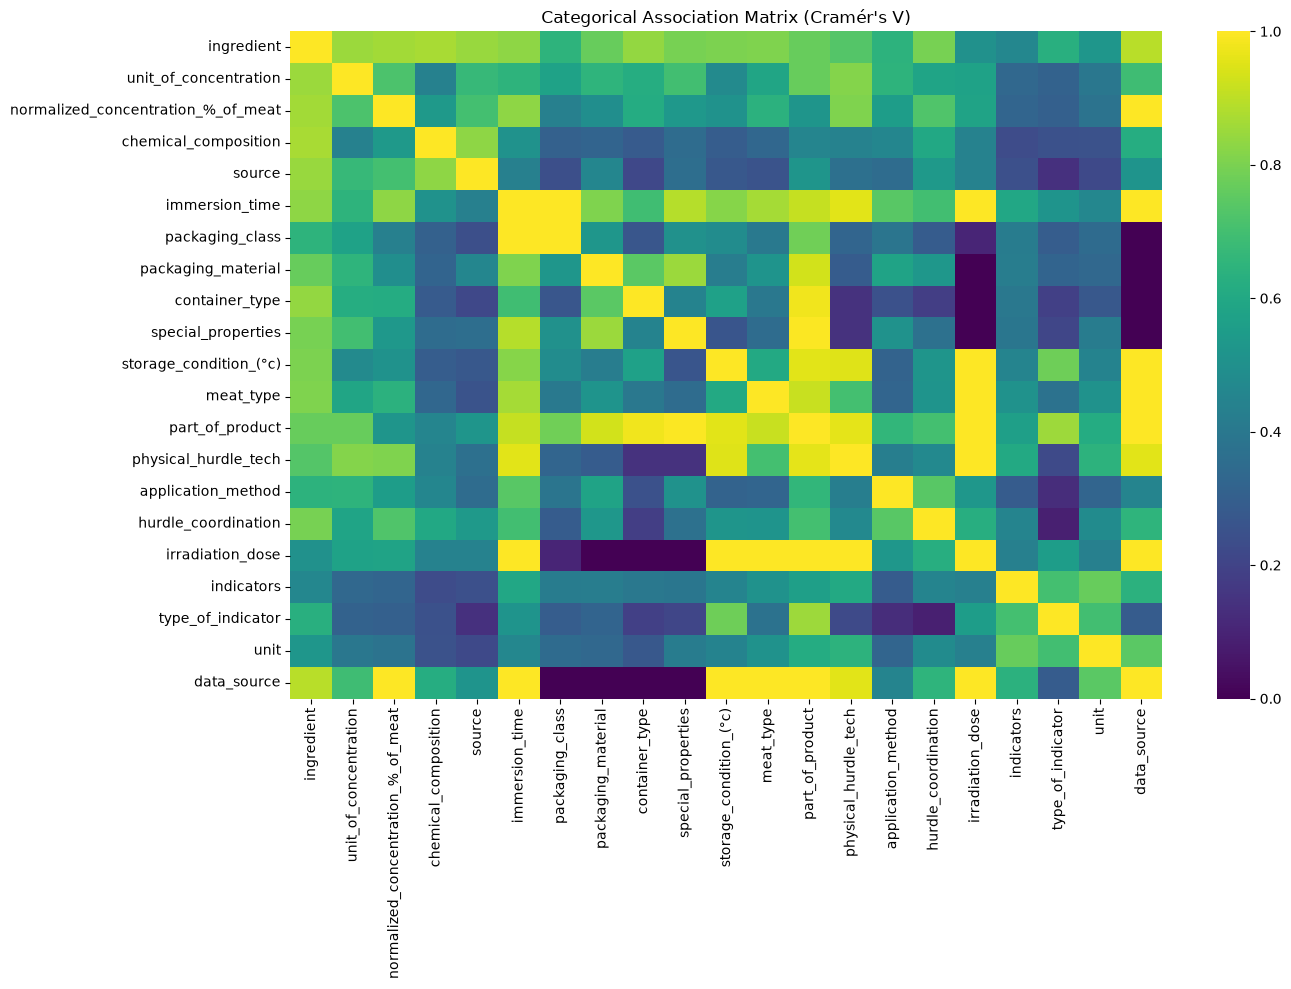

In [ ]:

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    if confusion.size == 0:
        return np.nan

    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape

    return np.sqrt((chi2 / n) / min(r - 1, k - 1)) if min(r, k) > 1 else 0.0

# pick only categorical columns
cat_df = combined.select_dtypes(include=["object", "category", "bool"]).copy()

# optionally convert low-cardinality numeric columns to categorical too
# example:
# cat_df["some_column"] = combined["some_column"].astype("category")

cols = cat_df.columns
assoc_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        assoc_matrix.loc[col1, col2] = cramers_v(cat_df[col1], cat_df[col2])

plt.figure(figsize=(14, 10))
sns.heatmap(assoc_matrix, cmap="viridis", vmin=0, vmax=1)
plt.title("Categorical Association Matrix (Cramér's V)")
plt.tight_layout()
plt.show()

In [38]:
for col1 in cols:
    for col2 in cols:
        if col1 != col2 and assoc_matrix.loc[col1, col2] > 0.8:
           print(col1, col2, assoc_matrix.loc[col1, col2])


ingredient unit_of_concentration 0.8485800000370626
ingredient normalized_concentration_%_of_meat 0.8595770454444831
ingredient chemical_composition 0.8676792185888774
ingredient source 0.8451542547285166
ingredient immersion_time 0.8293214777051393
ingredient container_type 0.8394123277013085
ingredient storage_condition_(°c) 0.8036988785992665
ingredient meat_type 0.8049704569370887
ingredient data_source 0.8935993338278639
unit_of_concentration ingredient 0.8485800000370626
unit_of_concentration physical_hurdle_tech 0.8152031732929234
normalized_concentration_%_of_meat ingredient 0.8595770454444831
normalized_concentration_%_of_meat immersion_time 0.8308693614976221
normalized_concentration_%_of_meat physical_hurdle_tech 0.8050657607547184
normalized_concentration_%_of_meat data_source 0.9999999999999999
chemical_composition ingredient 0.8676792185888774
chemical_composition source 0.8300732818694964
source ingredient 0.8451542547285166
source chemical_composition 0.8300732818694964

In [45]:
combined.columns

Index(['experiment_id', 'ingredient_id', 'ingredient', 'concentration',
       'unit_of_concentration', 'normalized_concentration_%_of_meat',
       'chemical_composition', 'source', 'immersion_time', 'packaging_class',
       'packaging_material', 'container_type', 'gas_CO2', 'gas_O2',
       'special_properties', 'storage_condition_(°c)', 'meat_type',
       'part_of_product', 'physical_hurdle_tech', 'application_method',
       'hurdle_coordination', 'irradiation_dose', 'indicators',
       'type_of_indicator', 'lower_level_threshold_(log_cfu/g)',
       'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count_(day_0)',
       'pre_threshold_(day)', 'pre_threshold_count',
       'initial_inhibition_factor', 'post_threshold_(day)',
       'post_threshold_count', 'post_inhibition_factor',
       'post_threshold_proximity_index_2(tpi)', 'data_source'],
      dtype='object')